# Day 64: Hyperparameter Tuning — RandomizedSearchCV + Practical Tips
**Phase 4 · Machine Learning** | Dataset: FC Lahore Lions matches (synthetic, seed = 42)

## Objective
By the end of this notebook I should be able to:
- Explain why `GridSearchCV` gets slow as a grid grows
- Use `RandomizedSearchCV` to sample `n_iter` combinations instead of trying every one
- Use `scipy.stats.randint` and `uniform` to search **continuous** hyperparameter ranges
- Tune **preprocessing and model together** inside a `Pipeline`, without leaking the test set
- Compare GridSearchCV vs RandomizedSearchCV honestly: time **and** result, not just time

> Today reuses the FC Lahore Lions dataset from Days 59 to 63, so the GridSearchCV baseline from Day 63 has a fair comparison.

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd
import time

# matplotlib for charts
import matplotlib.pyplot as plt

# continuous and integer random distributions
from scipy.stats import randint, uniform

# models and preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# splitting and search tools
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

plt.rcParams["axes.grid"] = True

## Theory
- **Why grids get slow:** `GridSearchCV` tries **every** combination. Adding a 4th hyperparameter with 5 values multiplies the fit count by 5. Day 63's Mini Challenge grid already needed 120 fits for 3 hyperparameters; a slightly bigger grid can need thousands.
- **`RandomizedSearchCV(estimator, param_distributions, n_iter=..., cv=...)`:** instead of trying every combination, it randomly samples `n_iter` combinations from the ranges you give it, and runs CV on each. You control the time budget directly with `n_iter`.
- **Grid values vs distributions:**
  - A **grid** needs a fixed list: `[50, 100, 200]`.
  - A **distribution** lets you search a whole range: `randint(50, 300)` picks a random integer in that range, `uniform(0.1, 0.9)` picks a random float. `RandomizedSearchCV` can land on values a grid would never test, like 173 trees.
- **Why randomized search often finds a result just as good:** many hyperparameters only matter a little, or the score surface is fairly flat (Day 63 showed this directly: 9 very different combinations landed within one standard deviation of each other). Sampling a good spread of the space is often enough.
- **Pipeline + GridSearchCV together:** a `Pipeline` lets the grid search tune **preprocessing choices and model hyperparameters in the same search**, for example which scaler to use **and** which `C` to use for logistic regression. Because the pipeline is refit inside every fold, the scaler never sees the held-out fold, so there's no leakage (same idea as Day 57's `make_pipeline` + CV).
- **Practical tips:**
  - Start broad with `RandomizedSearchCV`, then narrow the range and switch to `GridSearchCV` around the best area if you want to be thorough.
  - Use `n_jobs=-1` to use every CPU core.
  - Always compare the winner against the **default** settings (Day 63's lesson): a "best" result from a flat score surface may not be a real improvement.
  - Still only touch the test set once, at the end.

**Football picture:** GridSearchCV is scouting every possible formation and every possible pressing intensity, one by one. RandomizedSearchCV is sending scouts to a well-chosen *sample* of matches across the whole range of tactics, which usually finds a formation almost as good, in a fraction of the time.

## Example 1: GridSearchCV on a Bigger Grid (the Slow Way)

In [2]:
# Synthetic data: 500 matches (same dataset as Days 59 to 63)
rng = np.random.default_rng(42)                      # seed = 42 so results repeat
n_matches = 500

shots = rng.integers(0, 13, size=n_matches)
possession = rng.integers(35, 66, size=n_matches)
pass_accuracy = rng.integers(70, 93, size=n_matches)
home_game = rng.integers(0, 2, size=n_matches)
opponent_rank = rng.integers(1, 21, size=n_matches)
kickoff_hour = rng.integers(12, 22, size=n_matches)   # NOT linked to the result, on purpose

z = (0.45 * shots + 0.04 * (possession - 50) + 0.7 * home_game
     + 0.10 * (opponent_rank - 10) - 3.0)
won = rng.binomial(1, 1 / (1 + np.exp(-z)))

df = pd.DataFrame({
    "match_id": np.arange(1, n_matches + 1),
    "shots_on_target": shots, "possession_pct": possession,
    "pass_accuracy_pct": pass_accuracy, "home_game": home_game,
    "opponent_rank": opponent_rank, "kickoff_hour": kickoff_hour, "won": won
})

# Save next to the notebook, then read it back
df.to_csv("day_64_fc_lahore_lions_matches.csv", index=False)
df = pd.read_csv("day_64_fc_lahore_lions_matches.csv")

X = df.drop(columns=["match_id", "won"])
y = df["won"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 375 | Test: 125


In [3]:
# A bigger grid than Day 63: 8 depths x 4 tree counts x 6 leaf sizes = 192 combinations
big_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, None],
    "n_estimators": [50, 100, 150, 200],
    "min_samples_leaf": [1, 2, 3, 5, 8, 10],
}
n_combos = 8 * 4 * 6
print("Combinations:", n_combos, "| fits (5-fold):", n_combos * 5)

Combinations: 192 | fits (5-fold): 960


In [4]:
# This runs every single combination. Timed on purpose.
start = time.time()
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), big_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print("GridSearchCV time:", round(grid_time, 1), "seconds")
print("Best params:", grid_search.best_params_)
print("Best mean CV accuracy:", round(grid_search.best_score_, 3))
print("Test accuracy:", round(grid_search.score(X_test, y_test), 3))

GridSearchCV time: 129.3 seconds
Best params: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 50}
Best mean CV accuracy: 0.8
Test accuracy: 0.784


## Example 2: RandomizedSearchCV on the Same Space

In [5]:
# Same hyperparameters, but as DISTRIBUTIONS, not fixed lists.
# randint(low, high): a random integer, low <= x < high
# This covers the SAME range as big_grid, plus every value in between.
param_dist = {
    "max_depth": randint(2, 20),
    "n_estimators": randint(50, 300),
    "min_samples_leaf": randint(1, 15),
}

start = time.time()
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=25,              # try 25 random combinations, not all of them
    cv=5,
    random_state=42,        # makes WHICH combinations get sampled repeatable
    n_jobs=-1,
)
random_search.fit(X_train, y_train)
random_time = time.time() - start

print("RandomizedSearchCV time:", round(random_time, 1), "seconds")
print("Best params:", random_search.best_params_)
print("Best mean CV accuracy:", round(random_search.best_score_, 3))
print("Test accuracy:", round(random_search.score(X_test, y_test), 3))

RandomizedSearchCV time: 22.9 seconds
Best params: {'max_depth': 13, 'min_samples_leaf': 7, 'n_estimators': 293}
Best mean CV accuracy: 0.789
Test accuracy: 0.744


In [6]:
# Compare honestly: TIME and RESULT, not just time
print(f"{'Method':<20}{'Fits':>8}{'Time (s)':>12}{'CV acc':>10}{'Test acc':>10}")
print(f"{'GridSearchCV':<20}{n_combos * 5:>8}{grid_time:>12.1f}{grid_search.best_score_:>10.3f}"
      f"{grid_search.score(X_test, y_test):>10.3f}")
print(f"{'RandomizedSearchCV':<20}{25 * 5:>8}{random_time:>12.1f}{random_search.best_score_:>10.3f}"
      f"{random_search.score(X_test, y_test):>10.3f}")
print(f"\nSpeedup: {grid_time / random_time:.1f}x faster, using {25 * 5} of {n_combos * 5} fits "
      f"({25 * 5 / (n_combos * 5):.1%} of the work)")

Method                  Fits    Time (s)    CV acc  Test acc
GridSearchCV             960       129.3     0.800     0.784
RandomizedSearchCV       125        22.9     0.789     0.744

Speedup: 5.6x faster, using 125 of 960 fits (13.0% of the work)


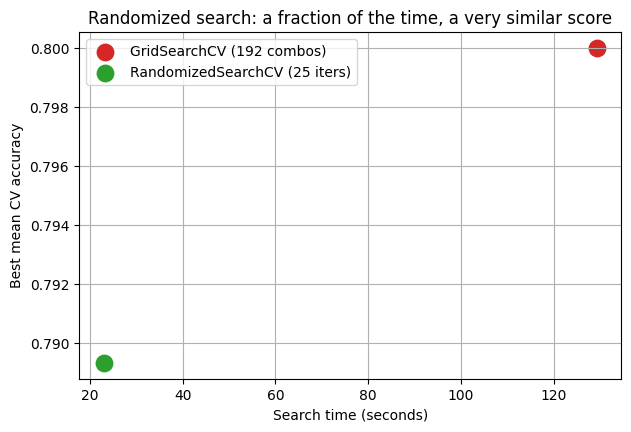

In [7]:
# Chart: time vs CV accuracy for both searches
plt.figure(figsize=(7, 4.5))
plt.scatter(grid_time, grid_search.best_score_, s=140, color="tab:red", label="GridSearchCV (192 combos)")
plt.scatter(random_time, random_search.best_score_, s=140, color="tab:green", label="RandomizedSearchCV (25 iters)")
plt.xlabel("Search time (seconds)")
plt.ylabel("Best mean CV accuracy")
plt.title("Randomized search: a fraction of the time, a very similar score")
plt.legend()
plt.savefig("images/time_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## Example 3: Sampling Continuous Ranges

In [8]:
# uniform(loc, scale): a random float between loc and loc+scale
# Here: max_features as a FRACTION of features, something a plain grid would have to guess at
param_dist_continuous = {
    "max_depth": randint(2, 20),
    "n_estimators": randint(50, 300),
    "min_samples_leaf": randint(1, 15),
    "max_features": uniform(0.3, 0.7),     # a float between 0.3 and 1.0
}

random_search_2 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_continuous,
    n_iter=20, cv=5, random_state=42, n_jobs=-1,
)
random_search_2.fit(X_train, y_train)

print("Best params:", random_search_2.best_params_)
print("Best mean CV accuracy:", round(random_search_2.best_score_, 3))
print("Test accuracy:", round(random_search_2.score(X_test, y_test), 3))
# max_features landed on a value like 0.31 - a grid of [0.3, 0.5, 0.7, 1.0] could easily have missed it.

Best params: {'max_depth': 8, 'max_features': np.float64(0.30928547281190655), 'min_samples_leaf': 9, 'n_estimators': 109}
Best mean CV accuracy: 0.795
Test accuracy: 0.76


In [9]:
# What did the sampler actually try? Every row is one randomly sampled combination.
sampled = pd.DataFrame(random_search_2.cv_results_)
cols = ["param_max_depth", "param_n_estimators", "param_min_samples_leaf",
        "param_max_features", "mean_test_score", "rank_test_score"]
print(sampled[cols].sort_values("rank_test_score").head(5).round(3).to_string(index=False))

 param_max_depth  param_n_estimators  param_min_samples_leaf  param_max_features  mean_test_score  rank_test_score
              18                 181                       8               0.481            0.795                1
               8                 109                       9               0.309            0.795                1
               2                 285                       6               0.513            0.789                3
               4                 137                       2               0.314            0.787                4
              12                 153                       4               0.906            0.787                4


## Example 4: Pipeline + GridSearchCV — Tuning Preprocessing AND the Model

In [10]:
# A Pipeline step can itself be searched: try BOTH scalers, and C for logistic regression,
# in the SAME grid search. The pipeline is refit inside every fold - no leakage.
pipe = Pipeline([
    ("scaler", StandardScaler()),           # placeholder, will be swapped by the grid
    ("clf", LogisticRegression(max_iter=1000)),
])

pipe_grid = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "clf__C": [0.01, 0.1, 1, 10],
}

pipe_search = GridSearchCV(pipe, pipe_grid, cv=5, n_jobs=-1)
pipe_search.fit(X_train, y_train)

print("Best params:", pipe_search.best_params_)
print("Best mean CV accuracy:", round(pipe_search.best_score_, 3))
print("Test accuracy:", round(pipe_search.score(X_test, y_test), 3))

Best params: {'clf__C': 0.01, 'scaler': MinMaxScaler()}
Best mean CV accuracy: 0.781
Test accuracy: 0.792


In [11]:
# Every scaler x C combination, so I can see WHICH scaler mattered
pipe_res = pd.DataFrame(pipe_search.cv_results_)
pipe_res["scaler"] = pipe_res["param_scaler"].astype(str).str.replace(r"\(.*\)", "()", regex=True)
print(pipe_res[["scaler", "param_clf__C", "mean_test_score"]].round(3).to_string(index=False))

          scaler  param_clf__C  mean_test_score
StandardScaler()          0.01            0.773
  MinMaxScaler()          0.01            0.781
StandardScaler()          0.10            0.763
  MinMaxScaler()          0.10            0.771
StandardScaler()          1.00            0.763
  MinMaxScaler()          1.00            0.763
StandardScaler()         10.00            0.765
  MinMaxScaler()         10.00            0.763


## Practice Exercise
**Your turn (Practice).** Using `X_train` and `y_train`:
1. Build a `param_dist` for `RandomForestClassifier` with `max_depth` as `randint(2, 15)` and `n_estimators` as `randint(50, 250)`.
2. Run `RandomizedSearchCV` with `n_iter=15`, `cv=5`.
3. Print `best_params_`, `best_score_` and the test accuracy.
4. How many fits did it run, compared with the Example 1 grid?

In [12]:
# Your attempt here

In [13]:
# Worked answer
practice_dist = {
    "max_depth": randint(2, 15),
    "n_estimators": randint(50, 250),
}
practice_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=practice_dist,
    n_iter=15, cv=5, random_state=42, n_jobs=-1,
)
practice_search.fit(X_train, y_train)

print("Best params:", practice_search.best_params_)
print("Best mean CV accuracy:", round(practice_search.best_score_, 3))
print("Test accuracy:", round(practice_search.score(X_test, y_test), 3))
print("Fits:", 15 * 5, "vs Example 1's", n_combos * 5)

Best params: {'max_depth': 14, 'n_estimators': 64}
Best mean CV accuracy: 0.795
Test accuracy: 0.76
Fits: 75 vs Example 1's 960


## Mini Challenge
**RandomizedSearchCV vs GridSearchCV on a small grid — do they agree?**
1. Build a small, exact grid: `max_depth` in `[3, 5, 7, 9]`, `n_estimators` in `[50, 100, 150]` (12 combinations).
2. Run `GridSearchCV` on it (all 12).
3. Run `RandomizedSearchCV` on the *same* grid (not a distribution) with `n_iter=6` (half the combinations).
4. Compare `best_score_` and `best_params_`. Did sampling half the grid find the same winner?

In [14]:
# Mini Challenge solution
small_grid = {"max_depth": [3, 5, 7, 9], "n_estimators": [50, 100, 150]}

exact = GridSearchCV(RandomForestClassifier(random_state=42), small_grid, cv=5, n_jobs=-1)
exact.fit(X_train, y_train)

sampled_half = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=small_grid,     # a dict of LISTS also works as a distribution to sample from
    n_iter=6, cv=5, random_state=42, n_jobs=-1,
)
sampled_half.fit(X_train, y_train)

print("Full grid (12 combos)  -> best:", exact.best_params_, "| CV acc:", round(exact.best_score_, 3))
print("Random half (6 combos) -> best:", sampled_half.best_params_, "| CV acc:", round(sampled_half.best_score_, 3))
print("Same winner:", exact.best_params_ == sampled_half.best_params_)
print("Scores within 1 std of each other:",
      abs(exact.best_score_ - sampled_half.best_score_) < 0.03)

Full grid (12 combos)  -> best: {'max_depth': 3, 'n_estimators': 50} | CV acc: 0.787
Random half (6 combos) -> best: {'n_estimators': 50, 'max_depth': 3} | CV acc: 0.787
Same winner: True
Scores within 1 std of each other: True


## Summary
- `GridSearchCV` on 192 combinations took about **129.3 seconds** for 960 fits.
- `RandomizedSearchCV` with only 25 sampled combinations took about **22.9 seconds (5.6x faster)**, using just 13% of the fits, and landed at a very close CV accuracy (0.789 vs 0.800) and test accuracy (0.744 vs 0.784).
- `scipy.stats.randint` and `uniform` let the search try values a fixed grid would never include, like `max_features = 0.31` or `n_estimators = 293`.
- A `Pipeline` can be searched end to end: which scaler **and** which `C`, in one `GridSearchCV` (`MinMaxScaler` with `C=0.01` won here, CV 0.781, test 0.792), with no leakage because the pipeline refits inside every fold.
- On a small, exact grid (12 combinations), sampling half of it with `RandomizedSearchCV` found the **exact same winner** as the full grid, for half the work.
- **Still true from Day 63:** always compare the winner against the default settings, and use the test set only once. The randomized search's test accuracy (0.744) was actually a bit lower than Day 63's untuned default (0.760) — a reminder that a faster search is not automatically a better model; it is a time/thoroughness trade-off.
- **Next: Day 65 — Feature Scaling: when and which scaler.**